In [1]:
import pandas as pd

import h2o
from h2o.automl import H2OAutoML
h2o.init()


Checking whether there is an H2O instance running at http://localhost:54321 ..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) 64-Bit Server VM (build 25.351-b10, mixed mode)
  Starting server from C:\Users\jake\AppData\Roaming\Python\Python311\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\jake\AppData\Local\Temp\tmp31vruotq
  JVM stdout: C:\Users\jake\AppData\Local\Temp\tmp31vruotq\h2o_jake_started_from_python.out
  JVM stderr: C:\Users\jake\AppData\Local\Temp\tmp31vruotq\h2o_jake_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,04 secs
H2O_cluster_timezone:,America/Los_Angeles
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.38.0.3
H2O_cluster_version_age:,1 month and 10 days
H2O_cluster_name:,H2O_from_python_jake_bt74yx
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,7.096 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


In [4]:
df = pd.read_csv('logs/ytmusic/reddit_all_manual_labels.tsv', sep='\t', index_col=0)
df = df.reset_index()

# add str based features
df['reddit_key_len'] = df['reddit_key'].str.len()
df['reddit_key_toks'] = df['reddit_key'].str.count(' ')
df['ytmusic_key_len'] =  df['ytmusic_key'].str.len()
df['ytmusic_key_toks'] = df['ytmusic_key'].str.count(' ')
df['key_len_diff'] = (df['reddit_key_len'] - df['ytmusic_key_len']).abs()

num_cols = [
    'match_score_token_set_ratio', 'match_score_token_sort_ratio', 
    'reddit_key_len', 'ytmusic_key_len', 'key_len_diff', 
    'reddit_key_toks', 'ytmusic_key_toks']
cat_cols = ['manual_label', 'reddit_sub']

df[num_cols] = df[num_cols].apply(pd.to_numeric)
df[cat_cols] = df[cat_cols].apply(pd.Categorical)
df = df[num_cols+cat_cols]

C:\Users\jake\AppData\Local\Temp\ipykernel_27844\846784425.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('logs/ytmusic/reddit_all_manual_labels.tsv', sep='\t', index_col=0)


In [5]:
train, test = h2o.H2OFrame(df).split_frame(ratios=[0.8], seed = 1)


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [7]:
aml = H2OAutoML(max_models =100,
                max_runtime_secs=3*60*60,
                balance_classes=True,
		seed =1)

aml.train(training_frame = train, y = 'manual_label')


AutoML progress: |
01:59:17.264: AutoML: XGBoost is not available; skipping it.

███████████████████████████████████████████████████████████████| (done) 100%


Model Details
=============
H2OGradientBoostingEstimator : Gradient Boosting Machine
Model Key: GBM_grid_1_AutoML_2_20230103_15917_model_27


Model Summary: 
    number_of_trees    number_of_internal_trees    model_size_in_bytes    min_depth    max_depth    mean_depth    min_leaves    max_leaves    mean_leaves
--  -----------------  --------------------------  ---------------------  -----------  -----------  ------------  ------------  ------------  -------------
    72                 72                          369988                 17           17           16.2917       1             442           325.069

ModelMetricsBinomial: gbm
** Reported on train data. **

MSE: 0.02050992842447327
RMSE: 0.1432128779980113
LogLoss: 0.074970810026522
Mean Per-Class Error: 0.022011345111579754
AUC: 0.9982821590434013
AUCPR: 0.9983513226603369
Gini: 0.9965643180868027

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.6519013975379698
              failed-match    passed-match    Error    Rate
------------  --------------  --------------  -------  ----------------
failed-match  30425           588             0.019    (588.0/31013.0)
passed-match  777             30225           0.0251   (777.0/31002.0)
Total         31202           30813           0.022    (1365.0/62015.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.651901     0.977918  143
max f2                       0.472846     0.982488  190
max f0point5                 0.822108     0.984843  93
max accuracy                 0.651901     0.977989  143
max precision                0.999557     1         0
max recall                   0.0828816    1         330
max specificity              0.999557     1         0
max absolute_mcc             0.651901     0.955996  143
max min_per_class_accuracy   0.622961     0.9773    150
max mean_per_class_accuracy  0.651901     0.977989  143
max tns                      0.999557     31013     0
max fns                      0.999557     21915     0
max fps                      0.00231547   31013     399
max tps                      0.0828816    31002     330
max tnr                      0.999557     1         0
max fnr                      0.999557     0.70689   0
max fpr                      0.00231547   1         399
max tpr                      0.0828816    1         330

Gains/Lift Table: Avg response rate: 49.99 %, avg score: 52.58 %
group    cumulative_data_fraction    lower_threshold    lift        cumulative_lift    response_rate    score       cumulative_response_rate    cumulative_score    capture_rate    cumulative_capture_rate    gain      cumulative_gain    kolmogorov_smirnov
-------  --------------------------  -----------------  ----------  -----------------  ---------------  ----------  --------------------------  ------------------  --------------  -------------------------  --------  -----------------  --------------------
1        0.0101588                   0.999665           2.00035     2.00035            1                0.999686    1                           0.999686            0.0203213       0.0203213                  100.035   100.035            0.0203213
2        0.0200113                   0.999642           2.00035     2.00035            1                0.999652    1                           0.999669            0.0197084       0.0400297                  100.035   100.035            0.0400297
3        0.0300411                   0.999623           2.00035     2.00035            1                0.999632    1                           0.999657            0.0200632       0.0600929                  100.035   100.035            0.0600929
4        0.0401032                   0.999608           2.00035     2.00035            1                0.999615    1                           0.999646            0.0201277       0.0802206                  100.035   100

In [8]:
lb = aml.leaderboard
lb.head(rows=lb.nrows)

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse
GBM_grid_1_AutoML_2_20230103_15917_model_27,0.991554,0.110967,0.99613,0.0533443,0.18158,0.0329713
GBM_grid_1_AutoML_2_20230103_15917_model_36,0.99147,0.111368,0.996091,0.0515403,0.181977,0.0331157
GBM_1_AutoML_2_20230103_15917,0.991465,0.111313,0.996104,0.0532713,0.182105,0.0331621
GBM_grid_1_AutoML_2_20230103_15917_model_16,0.991458,0.110643,0.99608,0.0512857,0.18189,0.0330841
GBM_grid_1_AutoML_2_20230103_15917_model_19,0.991434,0.110629,0.996072,0.0508211,0.181797,0.0330501
GBM_grid_1_AutoML_2_20230103_15917_model_30,0.991376,0.111207,0.996043,0.0505313,0.181695,0.033013
GBM_2_AutoML_2_20230103_15917,0.99137,0.112519,0.99604,0.0524648,0.182279,0.0332257
GBM_grid_1_AutoML_2_20230103_15917_model_17,0.99135,0.111436,0.996036,0.0517447,0.181525,0.0329511
GBM_grid_1_AutoML_2_20230103_15917_model_31,0.991329,0.111718,0.99601,0.0498959,0.182529,0.0333168
GBM_grid_1_AutoML_2_20230103_15917_model_9,0.99132,0.111577,0.996029,0.0510527,0.181362,0.0328921


In [9]:
best_model = aml.get_best_model()
print(best_model)

Model Details
H2OGradientBoostingEstimator : Gradient Boosting Machine
Model Key: GBM_grid_1_AutoML_2_20230103_15917_model_27


Model Summary: 
    number_of_trees    number_of_internal_trees    model_size_in_bytes    min_depth    max_depth    mean_depth    min_leaves    max_leaves    mean_leaves
--  -----------------  --------------------------  ---------------------  -----------  -----------  ------------  ------------  ------------  -------------
    72                 72                          369988                 17           17           16.2917       1             442           325.069

ModelMetricsBinomial: gbm
** Reported on train data. **

MSE: 0.02050992842447327
RMSE: 0.1432128779980113
LogLoss: 0.074970810026522
Mean Per-Class Error: 0.022011345111579754
AUC: 0.9982821590434013
AUCPR: 0.9983513226603369
Gini: 0.9965643180868027

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.6519013975379698
              failed-match    passed-match    Error    Rate
----------

In [10]:
best_model.model_performance(test)


ModelMetricsBinomial: gbm
** Reported on test data. **

MSE: 0.032883026730295556
RMSE: 0.18133677710353063
LogLoss: 0.11105536993550666
Mean Per-Class Error: 0.054661035337712965
AUC: 0.9914514181315546
AUCPR: 0.9961073190420956
Gini: 0.9829028362631091

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.44135475045475425
              failed-match    passed-match    Error    Rate
------------  --------------  --------------  -------  ---------------
failed-match  3306            301             0.0834   (301.0/3607.0)
passed-match  200             7530            0.0259   (200.0/7730.0)
Total         3506            7831            0.0442   (501.0/11337.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.441355     0.967804  220
max f2                       0.251859     0.976769  274
max f0point5                 0.791787     0.973816  122
max accuracy                 0.441355     0.955808  220
max precision                0.999602     1         0
max recall                   0.00332523   1         397
max specificity              0.999602     1         0
max absolute_mcc             0.441355     0.897571  220
max min_per_class_accuracy   0.673837     0.952005  156
max mean_per_class_accuracy  0.678457     0.952724  155
max tns                      0.999602     3607      0
max fns                      0.999602     6366      0
max fps                      0.00236338   3607      399
max tps                      0.00332523   7730      397
max tnr                      0.999602     1         0
max fnr                      0.999602     0.823545  0
max fpr                      0.00236338   1         399
max tpr                      0.00332523   1         397

Gains/Lift Table: Avg response rate: 68.18 %, avg score: 68.44 %
group    cumulative_data_fraction    lower_threshold    lift        cumulative_lift    response_rate    score       cumulative_response_rate    cumulative_score    capture_rate    cumulative_capture_rate    gain      cumulative_gain    kolmogorov_smirnov
-------  --------------------------  -----------------  ----------  -----------------  ---------------  ----------  --------------------------  ------------------  --------------  -------------------------  --------  -----------------  --------------------
1        0.0100556                   0.999675           1.46662     1.46662            1                0.999695    1                           0.999695            0.0147477       0.0147477                  46.6624   46.6624            0.0147477
2        0.0200229                   0.999653           1.46662     1.46662            1                0.999665    1                           0.99968             0.0146184       0.0293661                  46.6624   46.6624            0.0293661
3        0.0301667                   0.999637           1.46662     1.46662            1                0.999646    1                           0.999668            0.0148771       0.0442432                  46.6624   46.6624            0.0442432
4        0.0400459                   0.999623           1.46662     1.46662            1                0.99963     1                           0.999659            0.014489        0.0587322                  46.6624   46.6624            0.0587322
5        0.0500132                   0.999611           1.46662     1.46662            1                0.999617    1                           0.99965             0.0146184       0.0733506                  46.6624   46.6624            0.0733506
6        0.100026                    0.999563           1.46662     1.46662            1                0.999585    1                           0.999618            0.0733506       0.146701                   46.6624   46.6624            0.146701
7        0.15004                     0.999515           1.46662     1.46662            1             

# Leaderboard

> Leaderboard shows models with their metrics. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo
GBM_5_AutoML_2_20230103_15917,0.991473,0.110815,0.99611,0.0507795,0.180954,0.0327445,1941,0.022516,GBM
GBM_grid_1_AutoML_2_20230103_15917_model_27,0.991451,0.111055,0.996107,0.054661,0.181337,0.032883,2742,0.04718,GBM
GBM_grid_1_AutoML_2_20230103_15917_model_6,0.991443,0.111065,0.996119,0.0491159,0.181186,0.0328283,2093,0.041242,GBM
GBM_2_AutoML_2_20230103_15917,0.991361,0.112063,0.996065,0.0528496,0.182016,0.03313,1858,0.029916,GBM
GBM_1_AutoML_2_20230103_15917,0.99136,0.111451,0.996064,0.0515465,0.181897,0.0330866,3194,0.040747,GBM
GBM_grid_1_AutoML_2_20230103_15917_model_36,0.99133,0.111732,0.996035,0.0536814,0.181588,0.0329743,2106,0.036688,GBM
GBM_grid_1_AutoML_2_20230103_15917_model_12,0.991317,0.112692,0.99603,0.0491066,0.18216,0.0331823,1783,0.019496,GBM
GBM_grid_1_AutoML_2_20230103_15917_model_9,0.991307,0.112157,0.996033,0.05065,0.182594,0.0333405,2220,0.02741,GBM
GBM_grid_1_AutoML_2_20230103_15917_model_2,0.991293,0.1119,0.996045,0.0481547,0.181736,0.0330281,2117,0.021405,GBM
GBM_grid_1_AutoML_2_20230103_15917_model_29,0.991284,0.112664,0.996029,0.0507239,0.182126,0.0331699,1653,0.031345,GBM


# Confusion Matrix

> Confusion matrix shows a predicted class vs an actual class.

## GBM_grid_1_AutoML_2_20230103_15917_model_27

,failed-match,passed-match,Error,Rate
failed-match,3306.0,301.0,0.0834,(301.0/3607.0)
passed-match,200.0,7530.0,0.0259,(200.0/7730.0)
Total,3506.0,7831.0,0.0442,(501.0/11337.0)


# Variable Importance

> The variable importance plot shows the relative importance of the most important variables in the model.

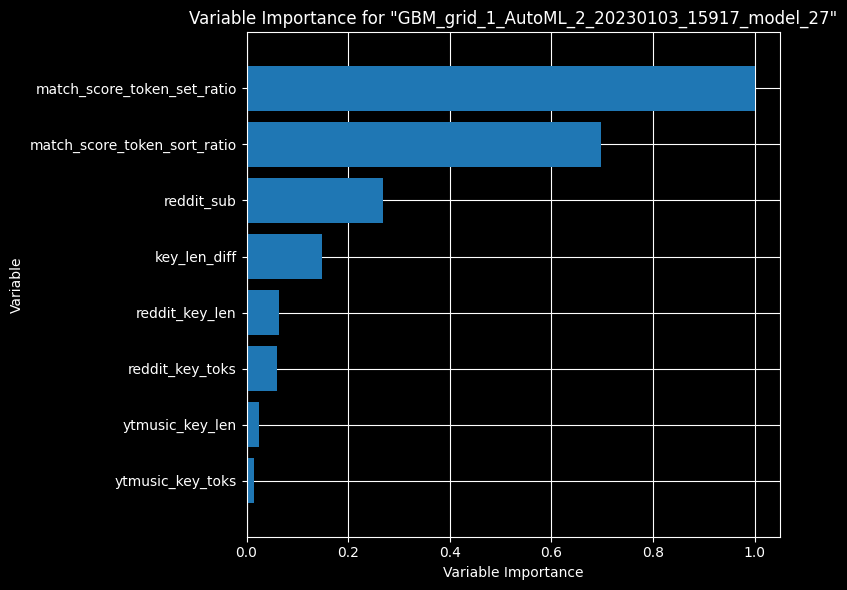

# Variable Importance Heatmap

> Variable importance heatmap shows variable importance across multiple models. Some models in H2O return variable importance for one-hot (binary indicator) encoded versions of categorical columns (e.g. Deep Learning, XGBoost). In order for the variable importance of categorical columns to be compared across all model types we compute a summarization of the the variable importance across all one-hot encoded features and return a single variable importance for the original categorical feature. By default, the models and variables are ordered by their similarity.

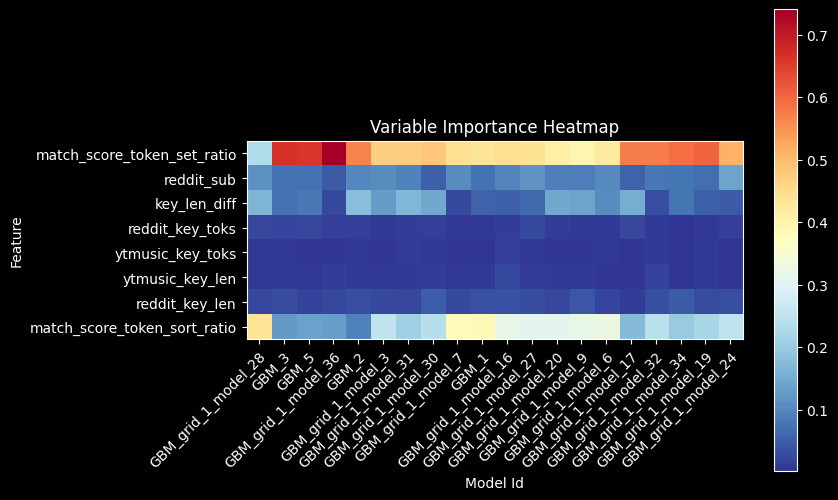

# Model Correlation

> This plot shows the correlation between the predictions of the models. For classification, frequency of identical predictions is used. By default, models are ordered by their similarity (as computed by hierarchical clustering). Interpretable models, such as GAM, GLM, and RuleFit are highlighted using red colored text.

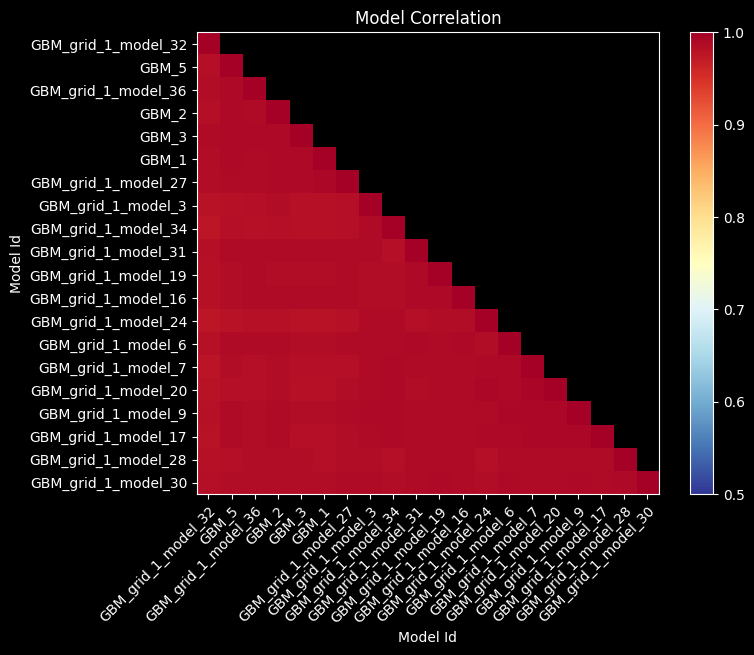

# SHAP Summary

> SHAP summary plot shows the contribution of the features for each instance (row of data). The sum of the feature contributions and the bias term is equal to the raw prediction of the model, i.e., prediction before applying inverse link function.

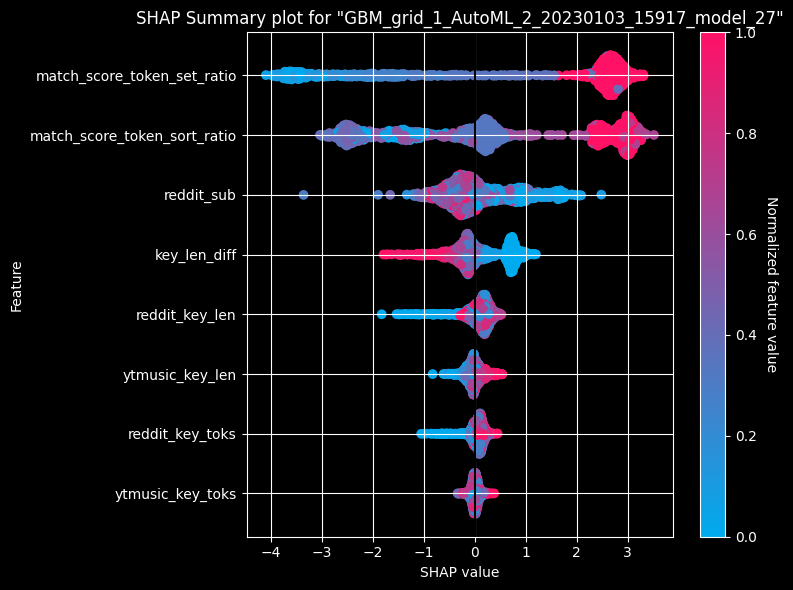

# Partial Dependence Plots

> Partial dependence plot (PDP) gives a graphical depiction of the marginal effect of a variable on the response. The effect of a variable is measured in change in the mean response. PDP assumes independence between the feature for which is the PDP computed and the rest.

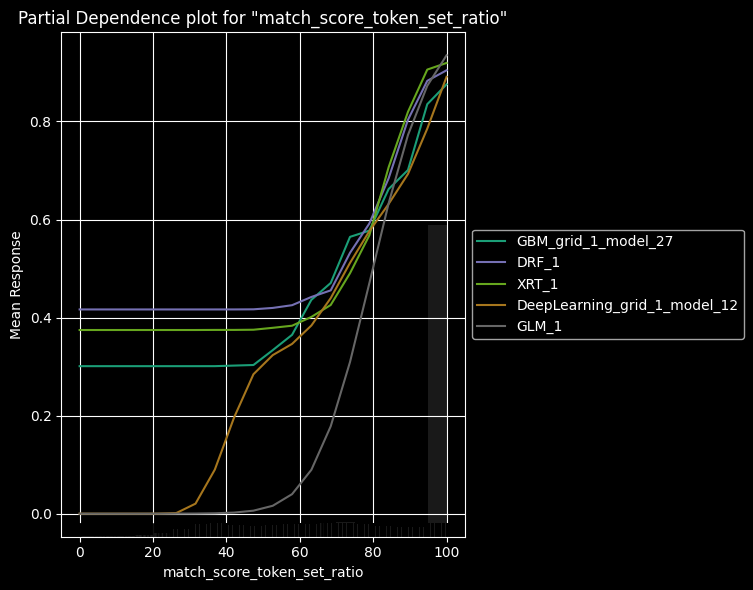

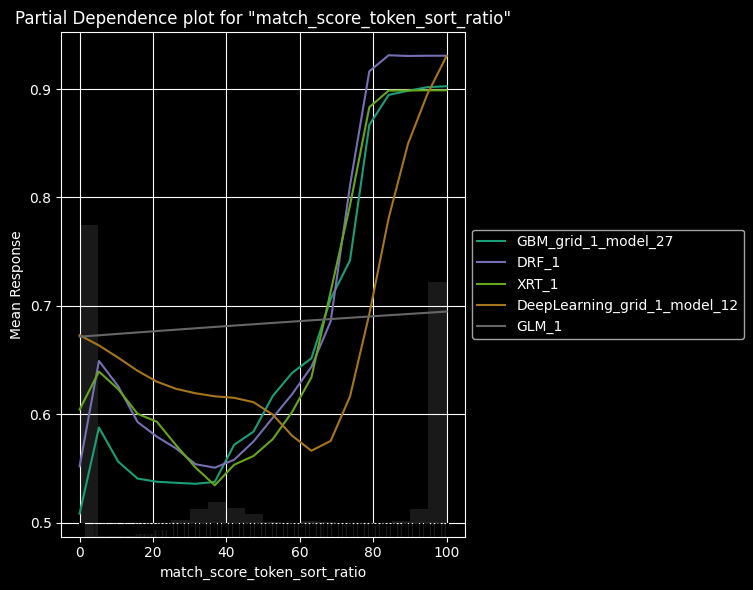

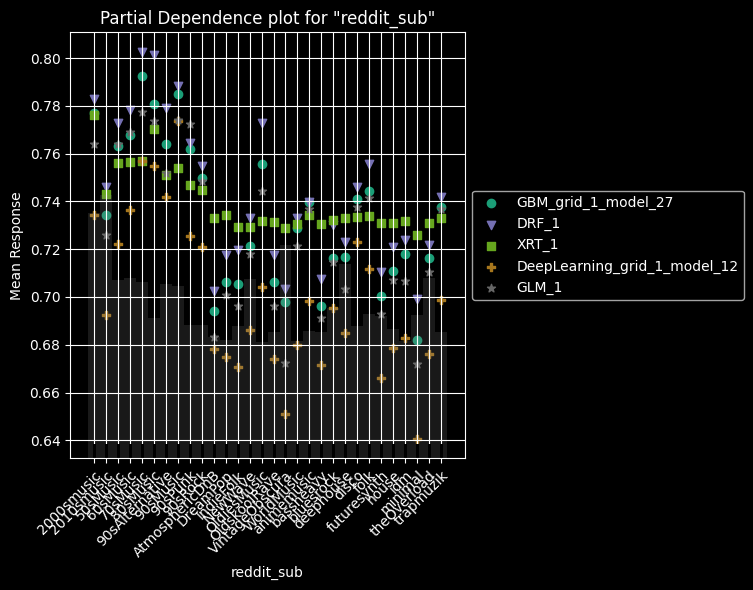

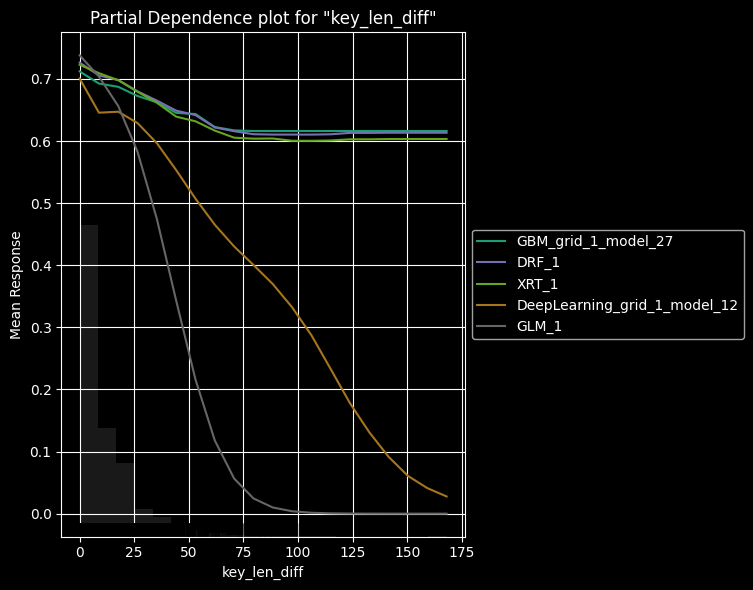

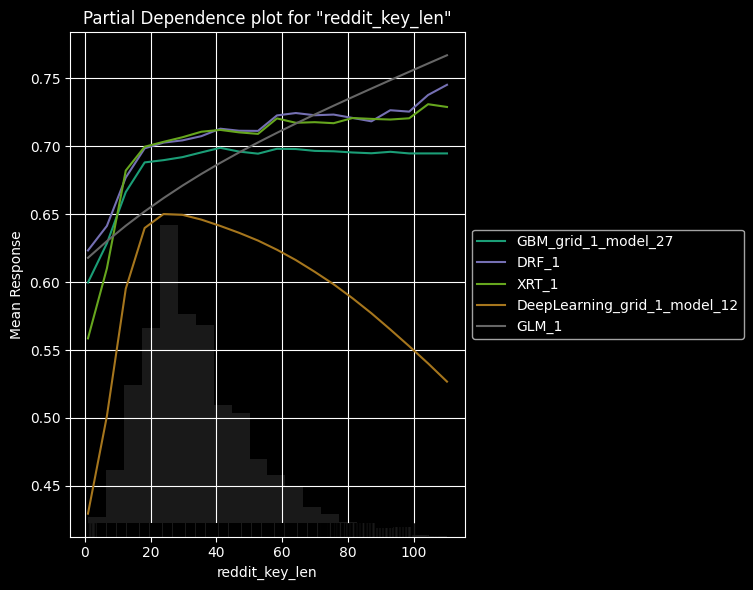

In [11]:
explain_model = aml.explain(frame = test, figsize = (8,6))


## OLD

In [ ]:

import sklearn.metrics
from sklearn.model_selection import train_test_split, StratifiedKFold
from autosklearn.classification import AutoSklearnClassifier
from autosklearn.metrics import (accuracy,
                                 f1,
                                 roc_auc,
                                 precision,
                                 average_precision,
                                 recall,
                                 log_loss)

In [ ]:
y = df.pop('manual_label')
X = df.copy()
TEST_RATIO = 0.2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = TEST_RATIO, random_state=1, stratify=y)
print(f'Split {len(y)} entires into {len(y_train)} train and {len(y_test)} test ({round(TEST_RATIO*100)}% test)')



Below are some of the parameters used in AutoSklearnClassifier.

```
time_left_for_this_task: Limit the total training time (in seconds)

max_models_on_disc: Limit the number of models to keep

memory_limit: The amount of memory (in MB) which we want to utilize

resampling_strategy: holdout or different kinds of cross validation. Refer to this documentation: https://automl.github.io/auto-sklearn/master/api.html

ensemble_size: Number of models to include in the ensemble. Auto-Sklearn provides an option to create ensemble after the individual models are created by taking the top ensemble_size number of models in a weighted fashion.

metric: A metric which we want to optimize

scoring_function: One or more metrics which we want to evaluate the model on
```

Under the hood, Auto-Sklearn constructs a Scikit-Learn pipeline during each trial. A Scikit-Learn pipeline is used to assemble a series of steps that performs data processing, feature processing and an estimator (classifier or regressor). The fit function trigger the entire Auto-Sklearn constructing, fitting and evaluating multiple Scikit-Learn pipeline until the stopping criteria time_left_for_this_task is met.

In [9]:
skf = StratifiedKFold(n_splits=5)
  
clf = AutoSklearnClassifier(time_left_for_this_task=600,
                            max_models_on_disc=10,
                            memory_limit = 10240/2,
                            resampling_strategy=skf,
                            ensemble_size = 3,
                            metric = average_precision,
                            scoring_functions=[roc_auc, average_precision, accuracy, f1, precision, recall, log_loss])

clf.fit(X = X_train, y = y_train)



/usr/local/lib/python3.10/site-packages/autosklearn/data/target_validator.py:187: UserWarning: Fitting transformer with a pandas series which has the dtype category. Inverse transform may not be able preserve dtype when converting to np.ndarray
  warnings.warn(


[ERROR] [2023-01-03 01:38:20,721:Client-AutoML(1):5b450b1c-8b4a-11ed-bea6-aaea007e9178] (' Dummy prediction failed with run state StatusType.CRASHED and additional output: {\'error\': \'Result queue is empty\', \'exit_status\': "<class \'pynisher.limit_function_call.AnythingException\'>", \'subprocess_stdout\': \'\', \'subprocess_stderr\': \'Process pynisher function call:\\nTraceback (most recent call last):\\n  File "/usr/local/Cellar/python@3.10/3.10.9/Frameworks/Python.framework/Versions/3.10/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap\\n    self.run()\\n  File "/usr/local/Cellar/python@3.10/3.10.9/Frameworks/Python.framework/Versions/3.10/lib/python3.10/multiprocessing/process.py", line 108, in run\\n    self._target(*self._args, **self._kwargs)\\n  File "/usr/local/lib/python3.10/site-packages/pynisher/limit_function_call.py", line 108, in subprocess_func\\n    resource.setrlimit(resource.RLIMIT_AS, (mem_in_b, mem_in_b))\\nValueError: current limit exceeds

ValueError: (' Dummy prediction failed with run state StatusType.CRASHED and additional output: {\'error\': \'Result queue is empty\', \'exit_status\': "<class \'pynisher.limit_function_call.AnythingException\'>", \'subprocess_stdout\': \'\', \'subprocess_stderr\': \'Process pynisher function call:\\nTraceback (most recent call last):\\n  File "/usr/local/Cellar/python@3.10/3.10.9/Frameworks/Python.framework/Versions/3.10/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap\\n    self.run()\\n  File "/usr/local/Cellar/python@3.10/3.10.9/Frameworks/Python.framework/Versions/3.10/lib/python3.10/multiprocessing/process.py", line 108, in run\\n    self._target(*self._args, **self._kwargs)\\n  File "/usr/local/lib/python3.10/site-packages/pynisher/limit_function_call.py", line 108, in subprocess_func\\n    resource.setrlimit(resource.RLIMIT_AS, (mem_in_b, mem_in_b))\\nValueError: current limit exceeds maximum limit\\n\', \'exitcode\': 1, \'configuration_origin\': \'DUMMY\'}.'

In [ ]:
clf.leaderboard(detailed = True, ensemble_only=False)

In [ ]:
clf.get_models_with_weights()

In [6]:
clf.sprint_statistics()


AttributeError: 'AutoMLClassifier' object has no attribute 'runhistory_'

In [ ]:
clf.refit(X = X_train, y = y_train)
dump(clf, 'model.joblib')
clf = load('model.joblib')
y_probas = clf.predict_proba(X_test)
pos_label = 'yes'
y_proba = y_probas[:, clf.classes_.tolist().index(pos_label)]

In [33]:
# add len query, rsult, diff, num spaces

df['manual_label'] = df['manual_label'].astype('category').cat.codes.astype(int)
df['reddit_sub'] = df['reddit_sub'].astype('category').cat.codes.astype(int)

feature_cols = [
    'match_score_token_set_ratio', 'match_score_token_sort_ratio', 
    'reddit_key_len', 'ytmusic_key_len', 'key_len_diff', 
    'reddit_key_toks', 'ytmusic_key_toks'
] 
            
predict_col = 'manual_label' # convert to 1/0

dataset = df[feature_cols + [predict_col]].dropna()

In [34]:
dataset

,match_score_token_set_ratio,match_score_token_sort_ratio,reddit_key_len,ytmusic_key_len,key_len_diff,reddit_key_toks,ytmusic_key_toks,manual_label
0,100,82,7.0,12.0,5.0,0.0,2.0,0
1,100,80,10.0,17.0,7.0,1.0,3.0,0
2,100,37,7.0,36.0,29.0,0.0,6.0,0
3,100,37,53.0,13.0,40.0,10.0,2.0,0
4,100,37,8.0,40.0,32.0,0.0,6.0,0
...,...,...,...,...,...,...,...,...
56610,50.0,38.0,43.0,18.0,25.0,6.0,3.0,0
56611,30.0,30.0,93.0,31.0,62.0,15.0,6.0,0
56612,63.0,36.0,13.0,33.0,20.0,2.0,4.0,0
56613,62.0,0.5,20.0,26.0,6.0,3.0,4.0,0
